<h1>Practical Exercise: Detecting Spruce/Fir Habitat using Logistic Regression</h1>

<h3>Komin Ivan

Group: IP-44</h3>

<h2>1. Introduction</h2>

The objective of this exercise is to apply machine learning to an environmental habitat detection problem. We are using the Forest Cover Type dataset to predict the presence of Spruce/Fir forest based on cartographic and environmental variables.  

Originally a multi-class problem, we have reformulated it into a binary classification task: detecting the positive class (Spruce/Fir) against all other cover types. This is highly relevant for environmental science as it supports habitat mapping and conservation planning. 

In this context, we face asymmetric costs: misclassifying other land-types as Spruce/Fir (False Positive) is often more severe for land management than missing a true habitat instance (False Negative).

<h2>2. Setup and Data Preparation</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, 
                             average_precision_score)
from sklearn.decomposition import PCA

# Ensure reproducibility 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. Load data from scikit-learn 
forest_data = fetch_covtype()
X = pd.DataFrame(forest_data.data)
y = forest_data.target

# 2. Subsample (N=50000) using stratified sampling for efficiency 
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=50000, stratify=y, random_state=RANDOM_STATE)

# 3. Reformulate into binary problem 
# Spruce/Fir is originally class 1. All others are 0.
y_binary = (y_sub == 1).astype(int) 

# Report class balance
pos_rate = y_binary.mean()
print(f"Positive class rate (Spruce/Fir): {pos_rate:.4f} ({pos_rate*100:.2f}%)")

Positive class rate (Spruce/Fir): 0.3646 (36.46%)


<h2>3. Data Description</h2>

The dataset consists of 50,000 instances. The target variable represents the presence (1) or absence (0) of Spruce/Fir forest.

| Feature Group | Count | Type | Meaning |
| :--- | :--- | :--- | :--- |
| **Continuous** | 10 | Numeric | Elevation, Slope, Hydrology distance, etc. |
| **Wilderness Areas** | 4 | Binary | One-hot encoded wilderness indicators. |
| **Soil Types** | 40 | Binary | One-hot encoded soil type indicators. |

Missing Data Handling: We checked for missing values across all features. If none are present, no further action is taken.  

No missing data; no action needed.


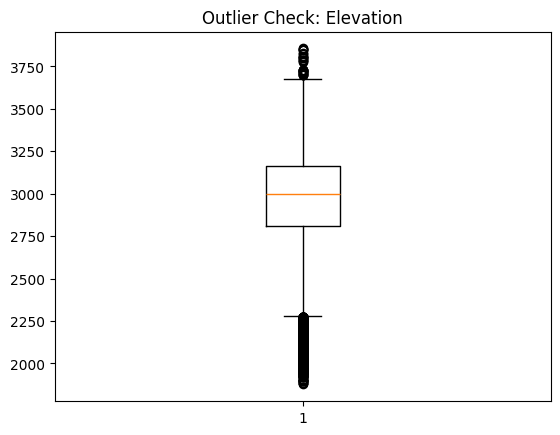

In [4]:
missing = X_sub.isnull().sum().sum()
if missing == 0:
    print("No missing data; no action needed.")
else:
    X_sub = X_sub.fillna(X_sub.median())
    print(f"Imputed {missing} values.")

# Optional: Basic outlier check for first continuous feature (Elevation)
plt.boxplot(X_sub.iloc[:, 0])
plt.title("Outlier Check: Elevation")
plt.show()

<h2>4. Methods</h2>

We used a 70/30 train-test split with stratify=y to maintain class distribution. Training data allows the model to learn patterns, while the test set evaluates its ability to generalize to new data.  

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_binary, test_size=0.3, stratify=y_binary, random_state=RANDOM_STATE
)

Before training, we analyze the scale of our features. This analysis must be performed on the training dataset to prevent information leakage from the test set.

In [6]:
# Analyze scales of the first 10 features
print("Feature Scales (First 10 continuous features):\n", X_train.iloc[:, :10].describe().loc[['min', 'max']])

Feature Scales (First 10 continuous features):
           0      1     2       3      4       5      6      7      8       9
min  1885.0    0.0   0.0     0.0 -152.0     0.0    0.0   96.0    0.0     0.0
max  3853.0  359.0  57.0  1343.0  589.0  7023.0  254.0  254.0  252.0  7141.0


The features have widely different ranges (e.g., Elevation ranges in thousands, while Slope is much smaller). Scaling is essential for Logistic Regression because the regularization penalty (L2) is applied to the magnitude of the coefficients; without scaling, features with larger ranges would dominate the penalty. 

We use a Pipeline with StandardScaler(with_mean=False). This is safer for this dataset because it contains many one-hot encoded (0/1) features for soil and wilderness areas

<h2>5. Baseline Model Training and Evaluation</h2>

We train a baseline Logistic Regression model. We select a range of metrics to evaluate performance, moving beyond simple accuracy to capture how the model handles the positive class .  

* **Accuracy**: Measures the proportion of correct predictions among all predictions. It answers the question: “How often is the model correct overall?”
* **Precision/Recall**: These metrics highlight the trade-off between false alarms and missed detections. Precision measures how often a positive prediction is actually correct, while Recall measures how many actual positive instances were correctly detected.
* **F1-Score**: The harmonic mean of precision and recall. It is particularly useful when both false positives and false negatives are important and when the dataset is imbalanced.
* **PR-AUC**: Summarizes the Precision-Recall curve into a single value. It is more sensitive to false positives and is highly informative for environmental datasets where positive cases (like specific habitat types) are rare.

In [7]:
# Baseline Pipeline
baseline_pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
])

baseline_pipe.fit(X_train, y_train)

# Evaluation function
def evaluate(model, X, y, set_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "Dataset": set_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "PR-AUC": average_precision_score(y, y_proba)
    }

metrics = pd.DataFrame([
    evaluate(baseline_pipe, X_train, y_train, "Train"),
    evaluate(baseline_pipe, X_test, y_test, "Test")
])
print(metrics)

  Dataset  Accuracy  Precision    Recall        F1    PR-AUC
0   Train  0.771600   0.696967  0.660920  0.678465  0.724878
1    Test  0.768667   0.695788  0.649479  0.671837  0.721018


<h2>6. Confusion Matrix and Environmental Interpretation</h2>

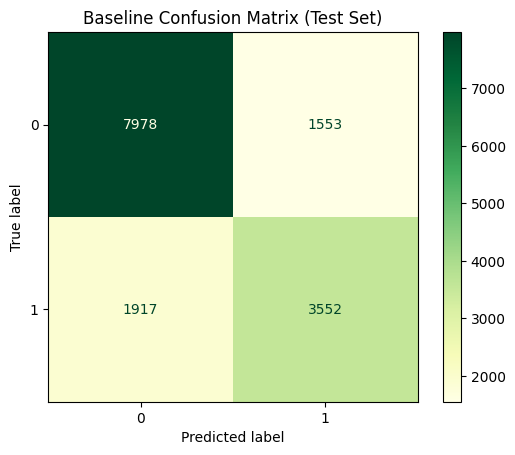

In [8]:
ConfusionMatrixDisplay.from_estimator(baseline_pipe, X_test, y_test, cmap='YlGn')
plt.title("Baseline Confusion Matrix (Test Set)")
plt.show()

Interpretation of Errors:
* **TP (True Positive)**: Correctly identified Spruce/Fir habitat.
* **TN (True Negative)**: Correctly identified non-Spruce/Fir area.
* **FP (False Positive)**: Model predicts "Spruce/Fir" but it is actually another cover type. This is environmentally risky because it produces a flawed habitat map, leading to wasted conservation efforts or wrong management decisions.
* **FN (False Negative)**: Model predicts "Other" but it is actually "Spruce/Fir." This is environmentally costly because the habitat may be left unprotected or underestimated.

In this habitat detection problem, the asymmetric costs mean we may prefer higher recall to ensure no true habitat is missed, even at the cost of more false alarms (lower precision).

<h2>7. Complexity Experiments: Underfitting and Overfitting</h2>

We now vary the polynomial degree (flexibility) and regularization strength <i>C</i> to observe model behavior.

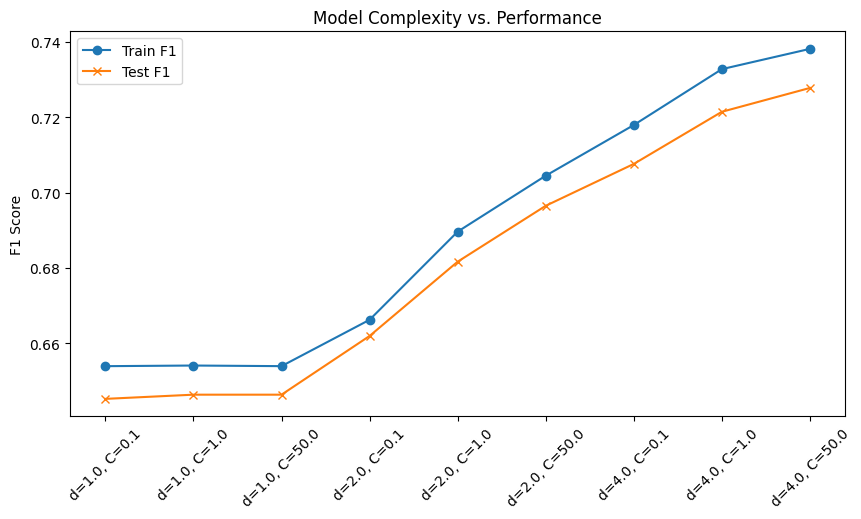

In [9]:
# Use only 10 continuous features for these experiments to avoid memory issues
X_tr_cont = X_train.iloc[:, :10]
X_te_cont = X_test.iloc[:, :10]

results = []
for d in [1, 2, 4]:
    for c in [0.1, 1.0, 50]:
        pipe = Pipeline([
            ('poly', PolynomialFeatures(degree=d, include_bias=False)),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(C=c, max_iter=5000, random_state=RANDOM_STATE))
        ])
        pipe.fit(X_tr_cont, y_train)
        
        f1_train = f1_score(y_train, pipe.predict(X_tr_cont))
        f1_test = f1_score(y_test, pipe.predict(X_te_cont))
        results.append({"Degree": d, "C": c, "F1_Train": f1_train, "F1_Test": f1_test})

res_df = pd.DataFrame(results)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(res_df.index, res_df['F1_Train'], label='Train F1', marker='o')
plt.plot(res_df.index, res_df['F1_Test'], label='Test F1', marker='x')
plt.xticks(res_df.index, [f"d={r['Degree']}, C={r['C']}" for _, r in res_df.iterrows()], rotation=45)
plt.ylabel("F1 Score")
plt.title("Model Complexity vs. Performance")
plt.legend()
plt.show()

Analysis of Underfitting and Overfitting:

<b>Underfitting</b>: Observed at Degree 1, C=0.1. The model is too simple (linear and heavily regularized) and shows low F1 scores on both the training and test sets.

<b>Overfitting</b>: Observed at Degree 4, C=50. The training F1 is significantly higher than the test F1, indicating the model has learned noise from the training data that does not generalize.

<h2>8. Decision Boundary Visualization (PCA)</h2>

We use PCA to reduce the features to two dimensions for visualization purposes, showing how the decision boundary becomes more complex.

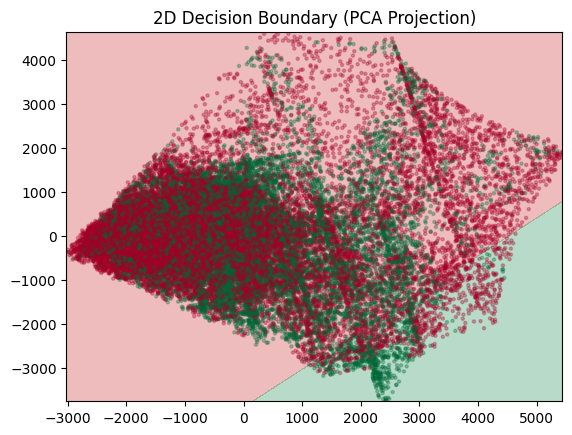

In [10]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Fit model on 2D data
vis_clf = LogisticRegression().fit(X_train_pca, y_train)

# Plotting
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))
Z = vis_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=5, alpha=0.3, cmap='RdYlGn')
plt.title("2D Decision Boundary (PCA Projection)")
plt.show()

We can conclude that while the linear model provides a clear decision rule, the high degree of overlap in the PCA space suggests that a simple linear boundary in these two dimensions is insufficient for reliable habitat mapping. This justifies the need for either more complex non-linear models or a broader set of features to improve recall for the Spruce/Fir habitat.

Based on the results of the practical exercise and the environmental objectives of habitat detection, the preferred choice is the Baseline Linear Logistic Regression model (typically with $C=1.0$ and degree 1 features). 

While a high-degree nonlinear model (e.g., degree 4) may achieve slightly higher accuracy on the training set, it often suffers from overfitting, meaning it learns noise rather than generalizable patterns. In contrast, the baseline linear model provides a more robust and reliable estimate for real-world environmental monitoring.

<h2>9. Discussion</h2>

<b>I. What are the risks of misclassification in environmental applications, for this example?</b>

In environmental applications like Spruce/Fir habitat detection, misclassification carries significant real-world risks because environmental phenomena are naturally complex, nonlinear, and multidimensional. A false positive occurs when the model predicts the presence of Spruce/Fir in a location that actually contains a different land-cover type. This is particularly risky because it generates flawed habitat maps, which can lead to misguided management and the inefficient allocation of conservation resources to areas that do not require them. 

Conversely, a false negative occurs when the model identifies an actual Spruce/Fir location as "Other," which is environmentally costly because it leads to habitat being underestimated or left under-protected. Because this is a habitat detection problem with asymmetric costs, understanding these errors is essential for informed decision-making; for instance, missing a true habitat instance is generally considered a less dangerous error than falsely identifying a non-habitat area for protection.  

<b>II. What is the role of scaling?</b>

Scaling plays a fundamental role in the preparation of data for Logistic Regression because the model’s regularization mechanism is directly sensitive to the scale of input features. Since regularization is used to control model complexity and prevent overfitting, features with larger numeric magnitudes could disproportionately influence the penalty term if they are left unscaled. 

For the Forest Cover Type dataset, which contains numerous binary one-hot encoded indicators for soil and wilderness areas, utilizing a pipeline with a scaler that avoids centering (with_mean=False) is a safer approach. This ensures that numerical environmental descriptors contribute appropriately to the model's coefficients and regularization process without disrupting the sparse structure of the categorical data indicators.  

<b> III. What would you do next if this were used for environmental monitoring? (e.g., threshold tuning/precision-recall trade-off, feature importance/interpretability)</b>

If this classifier were to be used for active environmental monitoring, several subsequent steps would be necessary to ensure its practical reliability for conservation planning. Beyond basic performance metrics, threshold tuning would be a priority to navigate the precision-recall trade-off, allowing practitioners to adjust the model's sensitivity based on the specific costs associated with false alarms or missed habitats. Investigating feature importance and model interpretability would also be essential to understand which environmental variables most strongly dictate habitat distribution, providing scientific insights into ecological dynamics. Finally, addressing current limitations such as the lack of a spatial component or the challenges posed by high-dimensional data would be a critical step for moving from a static classifier to a robust decision-support tool.  

<h2>10. Conclusion</h2>

Working with the dataset provided a practical demonstration of how machine learning can support environmental decision-making by mapping specific habitat distributions. Through the process of reformulating a multi-class problem into a binary classification task, it became evident that real-world environmental data requires a deep understanding of the ecological context to ensure that model outputs are both meaningful and actionable. The exercise emphasized that metric choice is critical, as standard measures like accuracy can be misleading in imbalanced datasets where the positive class of interest is rare. Instead, prioritizing measures such as Recall and PR-AUC proved essential for capturing the majority of true Spruce/Fir habitats.  

A significant takeaway from this analysis was the inherent trade-off between precision and recall, particularly when dealing with the asymmetric costs of misclassification. In habitat detection, the risk of a False Negative is often considered more environmentally costly than a False Positive, as it can lead to critical areas being left unprotected. Furthermore, the study of model complexity revealed important lessons about generalization. While increasing model flexibility through polynomial features can improve performance on training data, it also heightens the risk of overfitting, where the model learns noise rather than the broad environmental patterns necessary for reliable monitoring on unseen data.  